# Data Visualization


# Total Price by Country (Country Level Sales)

In [21]:
import pandas as pd
import plotly.express as px
%matplotlib inline

# Load your CSV
df = pd.read_csv("../data/gold/country_revenue.csv")

# Treemap
fig = px.treemap(
    df,
    path=["Country"],
    values="TotalPrice",
    color="TotalPrice",
    hover_data={"TotalPrice": ":,"},
    color_continuous_scale=[
        "#ede7f6",  # light lavender
        "#b39ddb",  # soft purple
        "#7e57c2",  # medium purple
        "#5e35b1",  # deep purple
        "#311b92"   # indigo
    ],
    title="Total Price by Country (Treemap)"
)

fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    font=dict(
        family="Segoe UI, Roboto, Arial",
        size=12,
        color="#333"
    )
)

fig.show()


In [22]:
import pandas as pd
import numpy as np
import plotly.express as px

df = (
    pd.read_csv("../data/gold/country_revenue.csv")
      .sort_values(by="TotalPrice", ascending=False)
)

world = px.data.gapminder()[["country"]].drop_duplicates()
world.columns = ["Country"]

merged = world.merge(df, on="Country", how="left")

# Log transform for smoother shading
merged["LogPrice"] = np.log1p(merged["TotalPrice"])

fig = px.choropleth(
    merged,
    locations="Country",
    locationmode="country names",
    color="LogPrice",
    hover_name="Country",
    hover_data={"TotalPrice": ":,"},
    color_continuous_scale=[
        "#f3e5f5",  # light lavender
        "#ce93d8",  # soft purple
        "#ab47bc",  # medium purple
        "#8e24aa",  # deep purple
        "#4a148c"   # indigo
    ],
)

fig.update_geos(
    projection_type="equirectangular",  # rectangular, no oval
    showcoastlines=False,
    showland=True,
    landcolor="#F2F2F2",
    lataxis_range=[-60, 85],  # crop poles to remove curvature
    lonaxis_range=[-180, 180],
    bgcolor="rgba(0,0,0,0)"
)

fig.update_traces(
    marker_line_width=0.4,
    marker_line_color="#A0A0A0"
)

fig.update_layout(
    title="Total Price by Country",
    title_x=0.5,
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title="Total Price (log scale)",
        thickness=12,
        len=0.75,
        ticks="outside"
    ),
    font=dict(
        family="Segoe UI, Roboto, Arial",
        size=12,
        color="#333"
    )
)

fig.show()


C:\Users\Wassem\AppData\Local\Temp\ipykernel_26456\1189124970.py:18: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



# Product Level Sales

### Revenue by Product Category

In [23]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/gold/category_revenue.csv")

# Group small categories into "Others"
threshold = 50000
df['Category'] = df.apply(
    lambda row: row['ProductCategory'] if row['TotalPrice'] >= threshold else 'Others',
    axis=1
)

df_grouped = df.groupby('Category', as_index=False)['TotalPrice'].sum()

fig = px.pie(
    df_grouped,
    names="Category",
    values="TotalPrice",
    hole=0.45,
    color="Category",
    color_discrete_sequence=[
        "#1F77B4", "#FF7F0E","#2CA02C","#9467BD", "#8C564B"
    ],
    title="Revenue by Product Category"
)

# Default: all labels inside
fig.update_traces(
    textinfo="label+percent",
    textposition="inside",
    pull=[0.35 if c == "Others" else 0 for c in df_grouped["Category"]],
    rotation=90
)

# --- Override ONLY the Others label to be outside ---
text_positions = []
for c in df_grouped["Category"]:
    if c == "Others":
        text_positions.append("outside")
    else:
        text_positions.append("inside")

fig.data[0].textposition = text_positions

fig.update_layout(
    width=650,
    height=500,
    margin=dict(l=0, r=0, t=40, b=0),
    font=dict(family="Segoe UI, Roboto, Arial", size=12, color="#333")
)

fig.show()


## Top 10 Products by Revenue

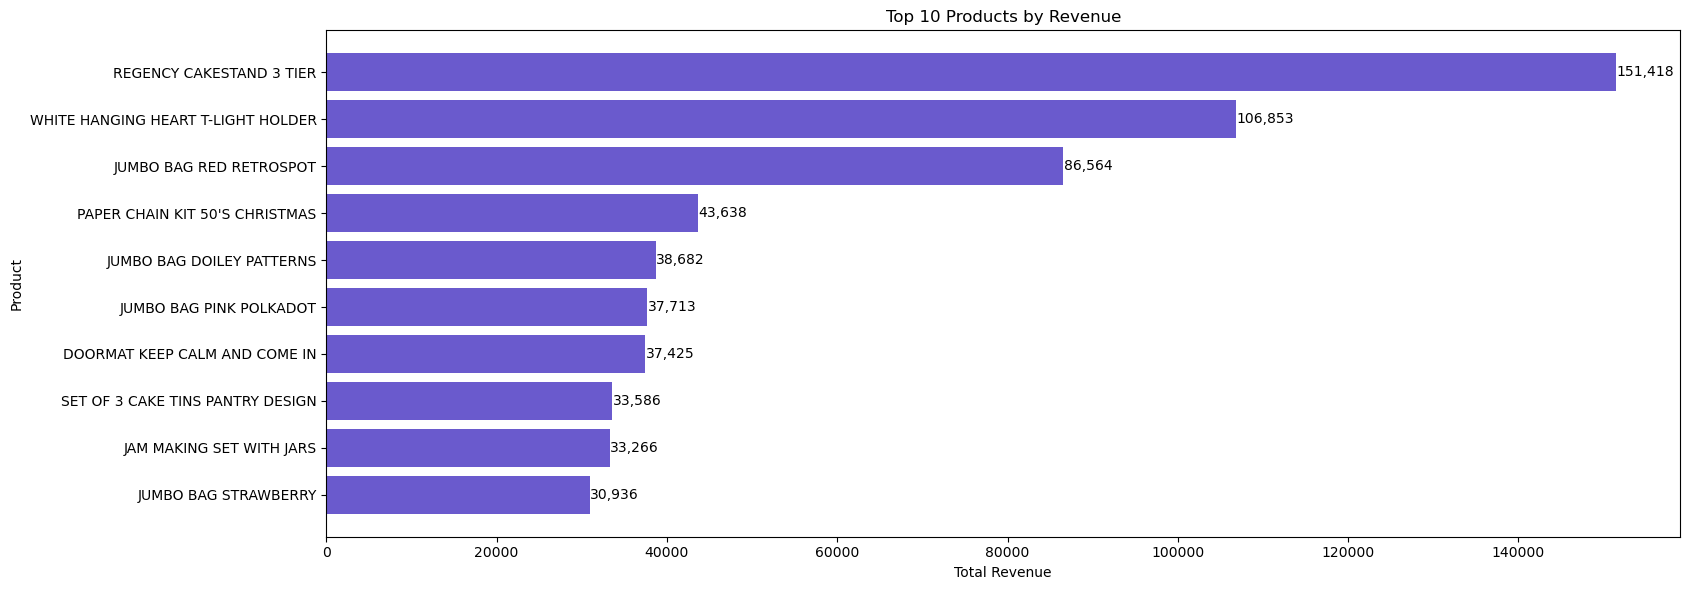

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/gold/product_revenue.csv")

# Group by StockCode + Description (handles duplicates)
df_grouped = df.groupby(["StockCode", "Description", "ProductCategory"], as_index=False)\
               .agg({"TotalRevenue": "sum", "TotalQuantity": "sum"})

# Sort and select top 10 products by revenue
top10 = df_grouped.sort_values(by="TotalRevenue", ascending=False).head(10)

# Plot
plt.figure(figsize=(17,6))
bars = plt.barh(top10["Description"], top10["TotalRevenue"], color="#6A5ACD")

plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()  # Highest revenue at top

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2,
             f"{width:,.0f}", va='center')

plt.tight_layout()
plt.show()



# Monthly Revenue Trend (2011)-(Time-Series Revenue)

In [25]:
import pandas as pd
import plotly.express as px

# Load and clean
df = pd.read_csv("../data/gold/monthly_revenue.csv")
df = df.drop(df.index[0])   # remove Dec 2010 row

# Create proper datetime column
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" +
                            df["Month"].astype(str) + "-01")

# Sort
df = df.sort_values("Date").reset_index(drop=True)

# Extract month names for x-axis
df["MonthName"] = df["Date"].dt.strftime("%b")   # Jan, Feb, Mar...

# Interactive line chart
fig = px.line(
    df,
    x="MonthName",
    y="TotalPrice",
    markers=True,
    title="Monthly Revenue Trend (2011)",
    labels={"TotalPrice": "Total Revenue", "MonthName": "Month"},
)

fig.update_traces(line=dict(color="#6C5CE7", width=3))

fig.update_layout(
    hovermode="x unified",
    title_font=dict(size=20, family="Arial", color="#333"),
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgray"),
    yaxis=dict(showgrid=True, gridcolor="lightgray")
)

fig.show()


# Customer Level Analysis

### Customer Segmentation Breakdown 

In [26]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/gold/customer_value.csv")

segment_counts = df["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]

fig = px.pie(
    segment_counts,
    names="Segment",
    values="Count",
    color="Segment",
    color_discrete_map={
        "High Value": "#6C5CE7",
        "Mid Value": "#00CEC9",
        "Low Value": "#E17055"
    }
)

fig.update_traces(
    textposition="inside",
    textinfo="label+percent"
)

# Center the title properly
fig.update_layout(
    title={
        'text': "Customer Segmentation Breakdown",
        'x': 0.5,
        'xanchor': 'center'
    },
    width=650,
    height=500,
    margin=dict(l=30, r=30, t=40, b=20),
    font=dict(
        family="Segoe UI, Roboto, Arial",
        size=12,
        color="#333"
    )
)

fig.show()


### Revenue vs Order Count

In [27]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df = pd.read_csv("../data/gold/customer_value.csv")

# -----------------------------
# Remove outliers using IQR
# -----------------------------
Q1 = df["TotalRevenue"].quantile(0.25)
Q3 = df["TotalRevenue"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[df["TotalRevenue"] <= upper_bound]

# -----------------------------
# Create subplot layout
# -----------------------------
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("With Outliers", "Without Outliers"),
    horizontal_spacing=0.12
)

# -----------------------------
# Scatter 1 — With Outliers
# -----------------------------
scatter1 = px.scatter(
    df,
    x="OrderCount",
    y="TotalRevenue",
    color="Segment",
    size="TotalQuantity",
    hover_data=["CustomerID", "AOV"],
    color_discrete_map={
        "High Value": "#6C5CE7",
        "Mid Value": "#00CEC9",
        "Low Value": "#E17055"
    }
)

# Add traces — legend ON for first subplot
for trace in scatter1.data:
    trace.showlegend = True
    fig.add_trace(trace, row=1, col=1)

# -----------------------------
# Scatter 2 — Without Outliers
# -----------------------------
scatter2 = px.scatter(
    df_filtered,
    x="OrderCount",
    y="TotalRevenue",
    color="Segment",
    size="TotalQuantity",
    hover_data=["CustomerID", "AOV"],
    color_discrete_map={
        "High Value": "#6C5CE7",
        "Mid Value": "#00CEC9",
        "Low Value": "#E17055"
    }
)

# Add traces — legend OFF for second subplot
for trace in scatter2.data:
    trace.showlegend = False
    fig.add_trace(trace, row=1, col=2)

# -----------------------------
# Axis Labels for BOTH plots
# -----------------------------
fig.update_xaxes(title_text="Order Count", row=1, col=1)
fig.update_yaxes(title_text="Total Revenue", row=1, col=1)

fig.update_xaxes(title_text="Order Count", row=1, col=2)
fig.update_yaxes(title_text="Total Revenue", row=1, col=2)

# -----------------------------
# Layout styling
# -----------------------------
fig.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color="white")))

fig.update_layout(
    title_text="Revenue vs Order Count — With & Without Outliers",
    title_x=0.5,
    width=1200,
    height=550,
    font=dict(family="Segoe UI, Roboto, Arial", size=12, color="#333")
)

fig.show()


we see is a strong positive relationship: as order count increases, total revenue rises. This confirms that frequency is a major driver of revenue in this dataset.

### AOV (Average Order Value) Distribution by Customer Segment

In [28]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/gold/customer_value.csv")

fig = px.histogram(
    df,
    x="AOV",
    color="Segment",
    opacity=0.75,
    color_discrete_map={
        "High Value": "#6C5CE7",
        "Mid Value": "#00CEC9",
        "Low Value": "#E17055"
    },
    title="AOV (Average Order Value) Distribution by Customer Segment"
)

# Force equal bin width (example: 100)
fig.update_traces(
    xbins=dict(
        start=0,
        end=4000,
        size=200   # each bin = 100 AOV wide
    )
)

fig.update_xaxes(range=[0, 1500])

fig.update_layout(
    width=800,
    height=550,
    xaxis_title="Average Order Value (AOV)",
    yaxis_title="Number of Customers",
    font=dict(family="Segoe UI, Roboto, Arial", size=12, color="#333"),
    bargap=0.05
)

fig.show()


### RFM Correlation Heatmap

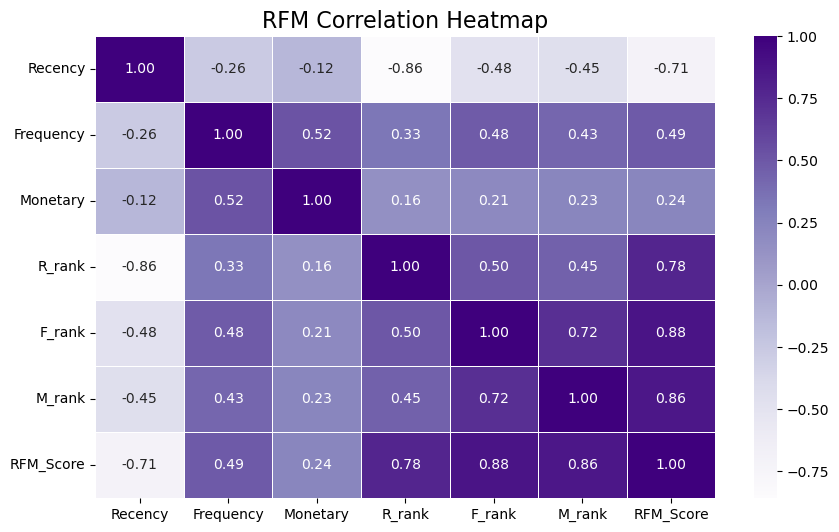

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your RFM dataset
df = pd.read_csv("../data/gold/rfm_scores.csv")

# Select only numeric RFM fields
rfm_numeric = df[["Recency", "Frequency", "Monetary", 
                  "R_rank", "F_rank", "M_rank", "RFM_Score"]]

# Compute correlation matrix
corr = rfm_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="Purples", linewidths=0.5, fmt=".2f")
plt.title("RFM Correlation Heatmap", fontsize=16)
plt.show()


Our RFM analysis shows that customer value in our business is driven mainly by recency and frequency. Recent buyers and frequent buyers consistently score the highest, forming strong Champion and Loyal segments. Monetary value matters, but far less than how often and how recently customers purchase. This tells us our biggest growth opportunity is strengthening loyalty and re‑engaging At‑Risk and Hibernating customers to boost repeat purchases

# Return / Cancellation Analysis

C:\Users\Wassem\AppData\Local\Temp\ipykernel_26456\3076229145.py:49: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



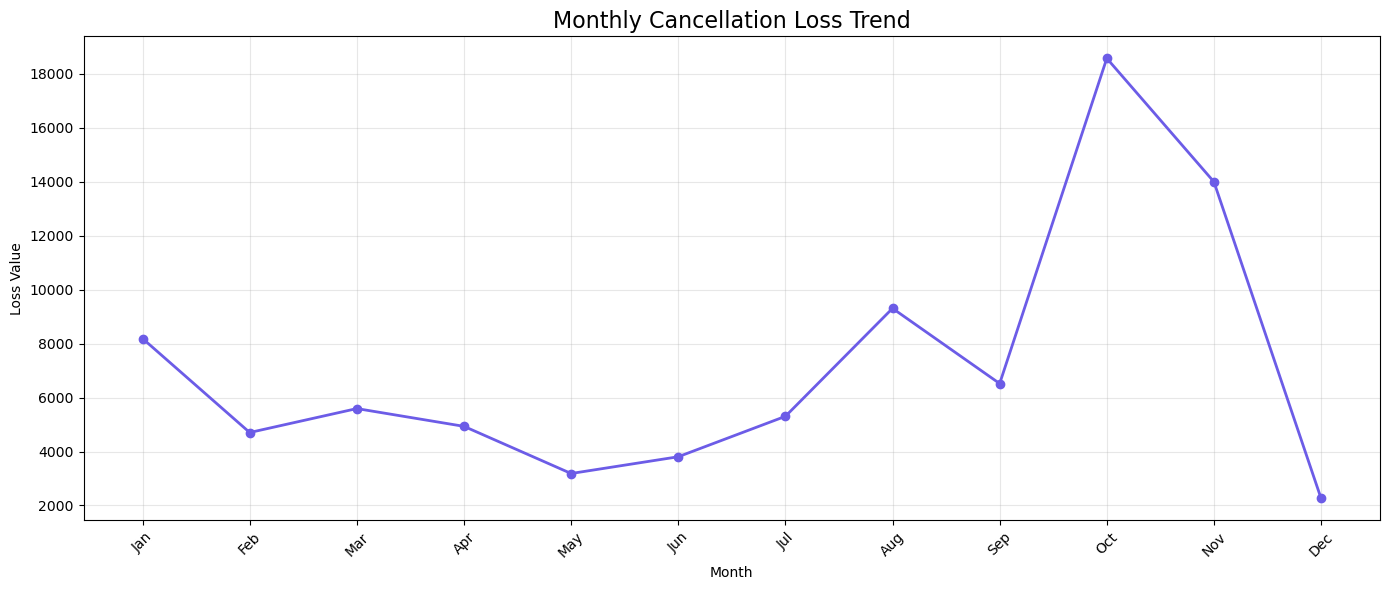

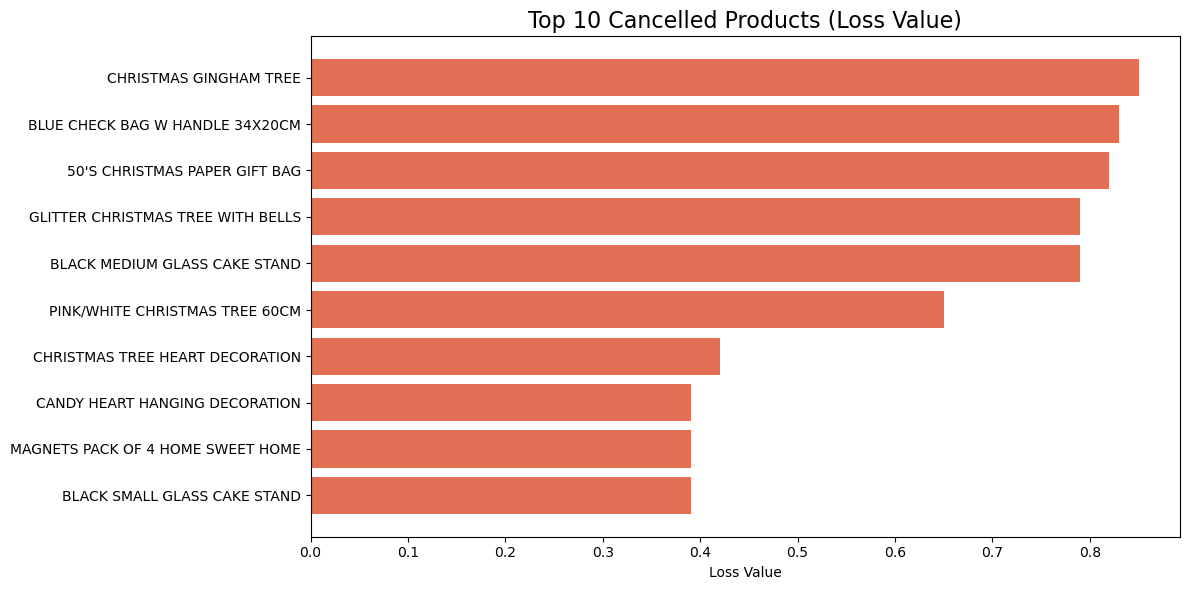

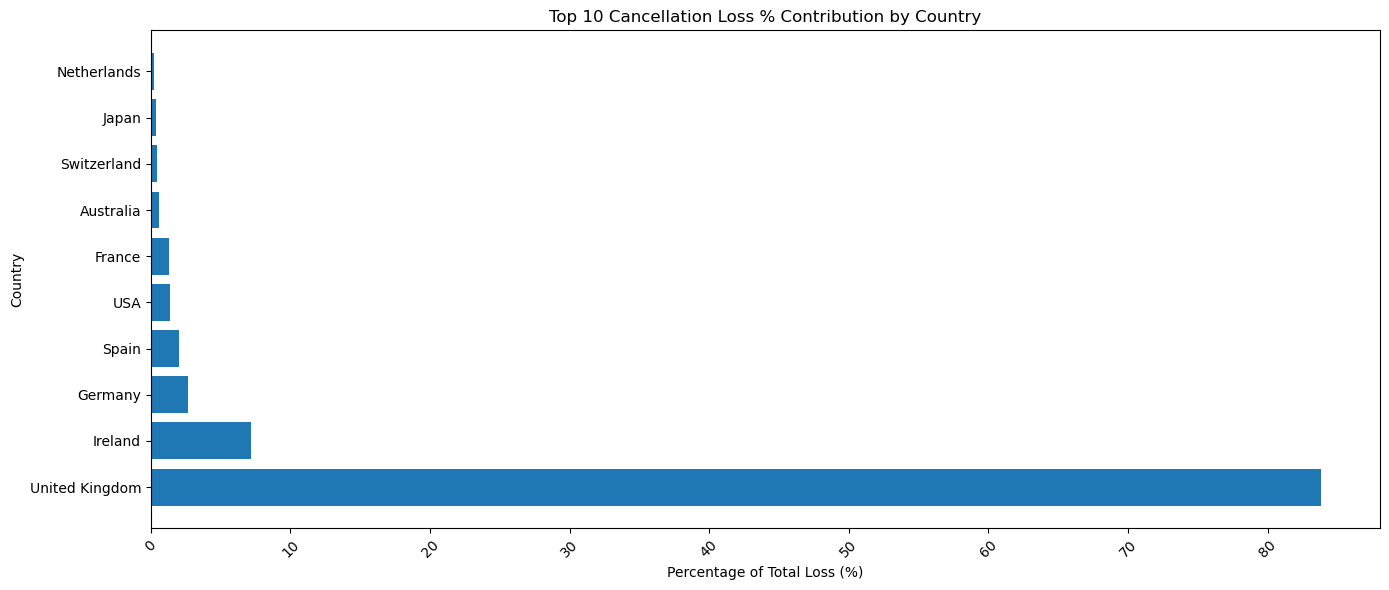

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. LOAD CANCELLED INVOICE DATASET
# ---------------------------------------------------
df = pd.read_csv("../data/silver/cancelled_invoices.csv")

# ---------------------------------------------------
# 2. CLEAN + STANDARDIZE
# ---------------------------------------------------
df["Country"] = df["Country"].replace({
    "EIRE": "Ireland",
    "RSA": "South Africa"
})
invalid_countries = ["European Community", "Unspecified", "Channel Islands"]

df = df[~df["Country"].isin(invalid_countries)].copy()
df = df[df["ProductCategory"] != "Other"].copy()
df = df[df["CustomerID"] != -1].copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# Compute cancellation loss value
df["LossValue"] = df["Quantity"] * df["UnitPrice"]

# Keep only cancelled rows (if Cancelled column exists)
if "Cancelled" in df.columns:
    df = df[df["Cancelled"] == True]

# ---------------------------------------------------
# 3. CREATE YEAR-MONTH
# ---------------------------------------------------
# Remove December 2010 data
df = df[df["InvoiceDate"] >= "2011-01-01"]

# Create Month Name column
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")   # Jan, Feb, Mar...

# Order months properly
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df["MonthName"] = pd.Categorical(df["MonthName"], categories=month_order, ordered=True)

# ---------------------------------------------------
# 4. AGGREGATIONS
# ---------------------------------------------------
# Monthly cancellation loss
monthly_cancel = df.groupby("MonthName")["LossValue"].sum().reset_index()

# Top cancelled products
top_products = (
    df.groupby("Description")["LossValue"]
    .sum()
    .sort_values()
    .head(10)
    .reset_index()
)

# Country-wise cancellations
country_cancel = (
    df.groupby("Country")["LossValue"]
    .sum()
    .sort_values()
    .reset_index()
)

# ---------------------------------------------------
# 5. VISUALIZATIONS
# ---------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(monthly_cancel["MonthName"], monthly_cancel["LossValue"],
         marker="o", color="#6C5CE7", linewidth=2)
plt.title("Monthly Cancellation Loss Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Loss Value")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top cancelled products
plt.figure(figsize=(12, 6))
plt.barh(top_products["Description"], top_products["LossValue"], color="#E17055")
plt.title("Top 10 Cancelled Products (Loss Value)", fontsize=16)
plt.xlabel("Loss Value")
plt.tight_layout()
plt.show()

# Country-wise cancellations
df["LossValue"] = df["Quantity"] * df["UnitPrice"]
#df = df[df["LossValue"] < 0]

country_loss = df.groupby("Country")["LossValue"].sum().reset_index().sort_values(by="LossValue", ascending=False).head(10)
country_loss["Percent"] = (country_loss["LossValue"] / country_loss["LossValue"].sum()) * 100

plt.figure(figsize=(14,6))
plt.barh(country_loss["Country"], country_loss["Percent"])
plt.title("Top 10 Cancellation Loss % Contribution by Country")
plt.ylabel("Country")
plt.xlabel("Percentage of Total Loss (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
